# CSCN8020 Assignment 3: Unitree G1 DQN

**Student:** Ce Chen  
**Student ID:** 9007166  
**Repository:** https://github.com/chence/CSCN8020_Assignment3

This notebook documents the completed student-written DQN, controlled epsilon-decay study, greedy benchmark evaluation, and comparison with the supplied rule-based policy. Training is performed by the modular scripts under `src/`; this notebook loads the submitted structured evidence so it can be reviewed without retraining.

## Environment and task

The observation is `[elbow angle, elbow velocity, goal angle, goal - elbow angle]`. Actions are decrease (0), hold (1), and increase (2). Goals are sampled uniformly from `[-0.8, 0.8]` radians. Success requires remaining within 0.04 radians for eight consecutive steps. True success termination masks Bellman bootstrapping; a 150-step time-limit truncation ends collection but remains eligible for bootstrapping.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
assert (ROOT / 'models/selected_dqn.pt').is_file()
print('Checkpoint and project paths verified.')

Checkpoint and project paths verified.


## Student-written DQN

`src/dqn/q_network.py` implements a 4-64-64-3 MLP with ReLU activations and no output softmax. `ReplayBuffer` provides bounded random mini-batches. `DQNAgent` owns separate online and target networks, epsilon-greedy selection, Huber loss, Adam optimization, gradient clipping, target synchronization every 250 optimization steps, and checkpoint save/load support. The required baseline uses gamma 0.95, learning rate 0.001, batch size 64, capacity 50,000, and a 500-transition warm-up.

In [2]:
from dqn import DQNAgent
agent, metadata = DQNAgent.load(ROOT / 'models/selected_dqn.pt', device='cpu')
print(metadata)
print(agent.online_network)

{'config_name': 'config_a', 'seed': 42, 'epsilon_decay': 0.995, 'epsilon_final': 0.05, 'episodes_completed': 600, 'training_seconds': 23.727217208128422, 'goal_range': [-0.8, 0.8], 'truncation_treatment': 'bootstrap across time-limit truncation'}
QNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


## Controlled epsilon-decay experiment

Configuration A uses decay 0.995 and Configuration B uses 0.985. All other hyperparameters and the seed policy are held constant.

In [3]:
comparison = pd.read_csv(ROOT / 'results/epsilon_decay_comparison.csv')
comparison

,configuration,epsilon_decay,training_episodes,training_seconds,final_epsilon,final_20_mean_training_reward,final_50_training_success_rate,evaluation_success_rate,mean_evaluation_reward,mean_evaluation_length,mean_final_absolute_error
0,config_a,0.995,600,23.727217,0.05,14.274504,1,1.0,13.278066,19.75,0.006761
1,config_b,0.985,600,18.238784,0.05,14.193562,1,1.0,13.225110,19.25,0.008558


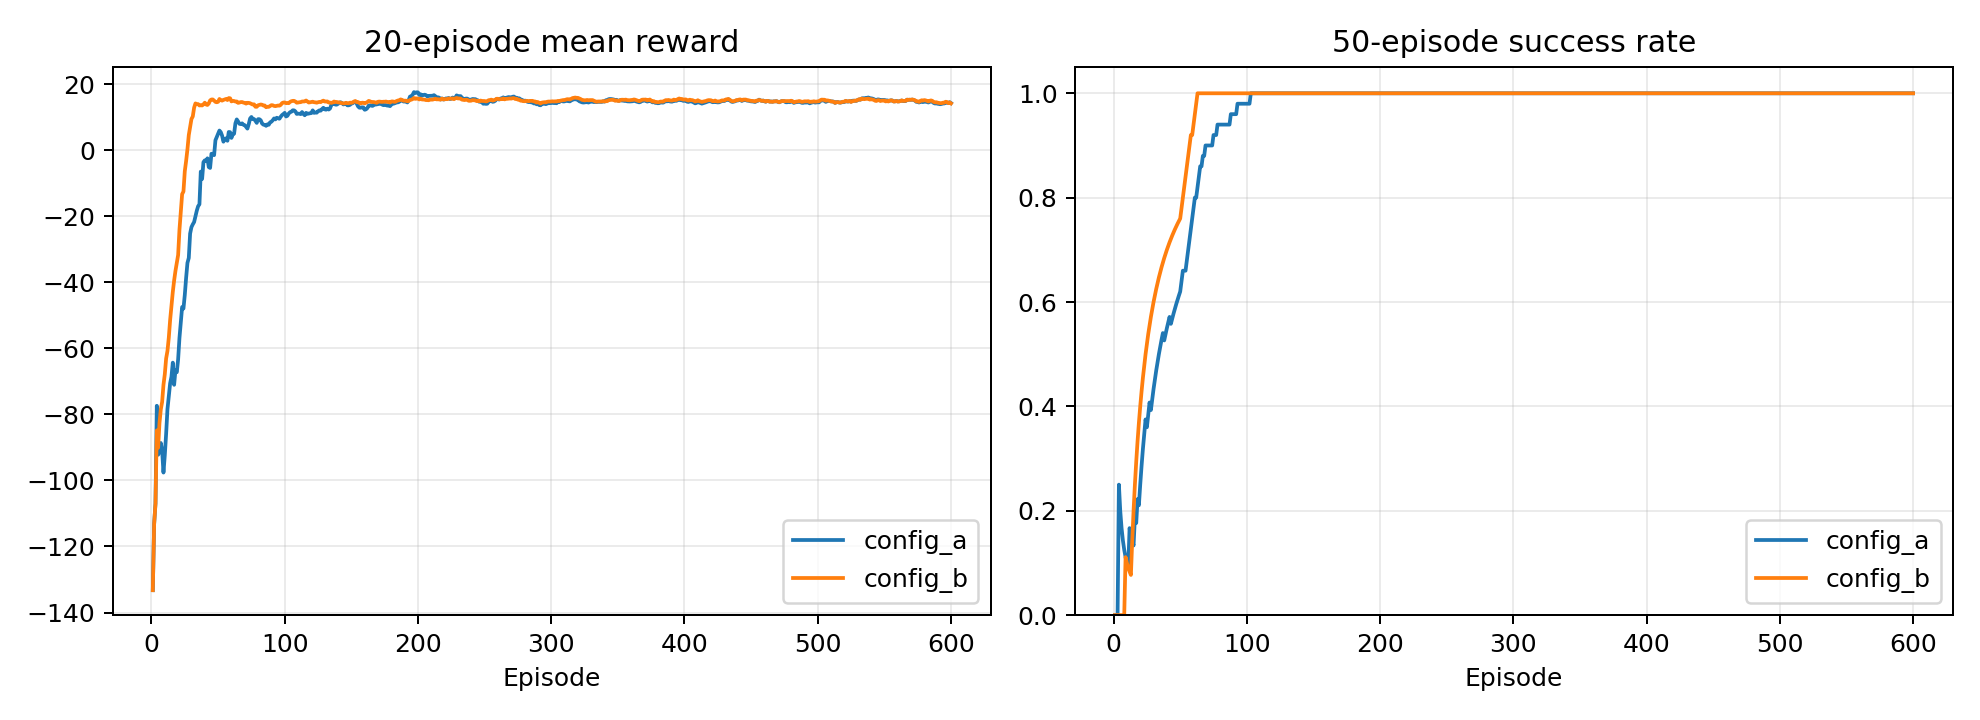

In [4]:
display(Image(filename=str(ROOT / 'results/epsilon_decay_comparison.png')))

## Model selection conclusion

**Configuration A (`config_a`) was selected because it matched Configuration B's success while providing stronger reward and final-error results in the comparison above.**

### Selected model checkpoint

Based on the controlled comparison above, **Configuration A (`config_a`)** is the selected model. It preserves the 100% greedy success rate while providing the higher mean evaluation reward and lower mean final absolute error. The following cell verifies that the submitted checkpoint contains Configuration A metadata.

In [5]:
selected_checkpoint = ROOT / 'models/selected_dqn.pt'
selected_agent, selected_metadata = DQNAgent.load(selected_checkpoint, device='cpu')
assert selected_metadata['config_name'] == 'config_a'
print(f'Selected checkpoint: {selected_checkpoint.relative_to(ROOT)}')
print('Source configuration: Configuration A (config_a)')
print(f"Epsilon decay: {selected_metadata['epsilon_decay']}")
print(f"Training seed: {selected_metadata['seed']}")
print(f"Training episodes: {selected_metadata['episodes_completed']}")

Selected checkpoint: models/selected_dqn.pt
Source configuration: Configuration A (config_a)
Epsilon decay: 0.995
Training seed: 42
Training episodes: 600


## Greedy evaluation by target angle

In [6]:
evaluation = pd.read_csv(ROOT / 'results/config_a/dqn_evaluation_summary.csv')
evaluation

,goal,episodes,successes,success_rate,mean_reward,mean_episode_length,mean_final_absolute_error
0,-0.8,5,5,1.0,11.058340,22.00,0.001484
1,-0.4,5,5,1.0,15.447120,17.00,0.005478
2,+0.4,5,5,1.0,15.579138,17.00,0.012998
3,+0.8,5,5,1.0,11.027667,23.00,0.007084
4,overall,20,20,1.0,13.278066,19.75,0.006761


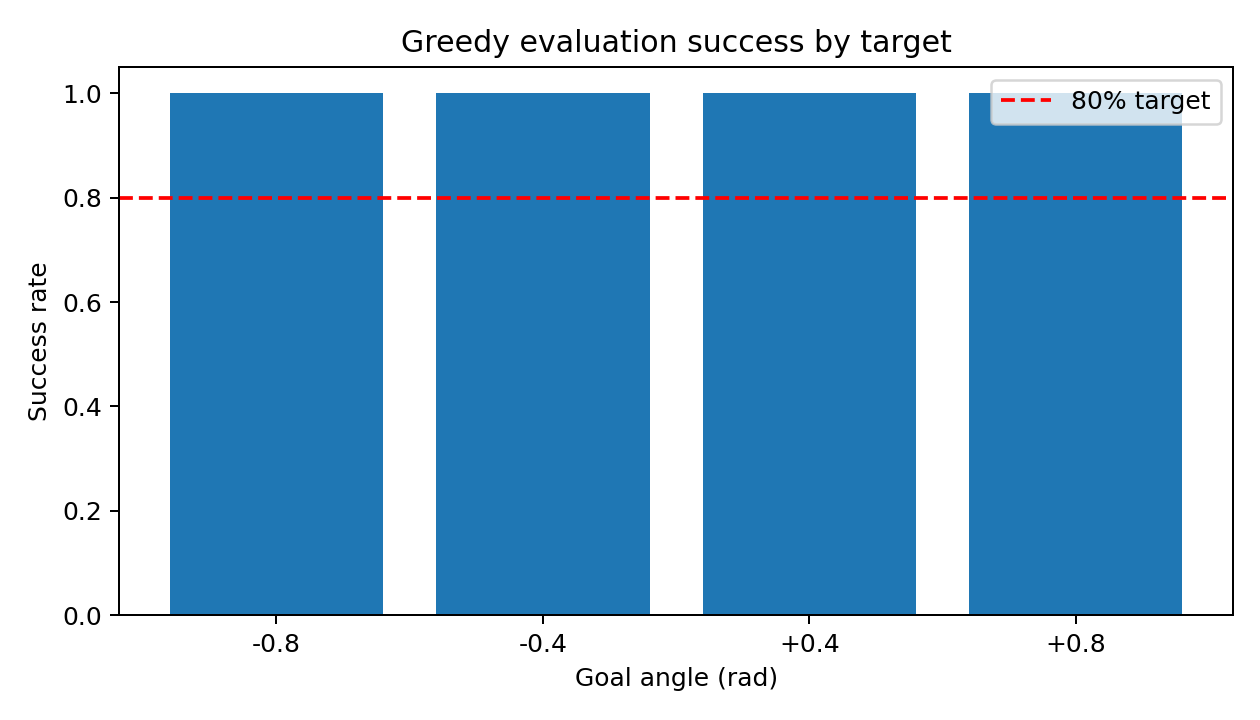

In [7]:
display(Image(filename=str(ROOT / 'results/config_a/evaluation_success_by_goal.png')))

## Final evaluation conclusion

**The selected DQN exceeded the required success threshold at every benchmark goal.**

## Rule-based policy comparison

In [8]:
policy_comparison = pd.read_csv(ROOT / 'results/rule_based_vs_selected_dqn.csv')
policy_comparison

,policy,successes,episodes,success_rate,mean_cumulative_reward,mean_episode_length,mean_final_absolute_error
0,rule_based,20,20,1.0,12.866629,24.00,0.012209
1,selected_dqn_config_a,20,20,1.0,13.278066,19.75,0.006761


## Final policy comparison conclusion

**The selected DQN matched the rule-based policy's success while achieving stronger reward, episode-length, and final-error results in the comparison above.**

The rule-based policy remains more sample efficient because it requires no training. Limitations include one training seed, simulation-only validation, four benchmark goals, and dependence on reward shaping. Future work should repeat multiple seeds and test denser unseen goals.

## Reproduction commands

```bash
python -m pip install -r requirements.txt
PYTHONPATH=src python src/test_g1_elbow_env.py
PYTHONPATH=src python src/evaluate_dqn.py --checkpoint models/selected_dqn.pt --output-dir results/selected
# macOS continuous rendered demonstration
PYTHONPATH=src mjpython src/render_dqn_policy.py --checkpoint models/selected_dqn.pt --goals -0.8 -0.4 0.8 0.4 0.0 --continuous --interactive --step-delay 0.08
```

On Linux or WSLg, replace `mjpython` with `python`. The continuous command is used only for the visual demonstration: it preserves the physical robot state while changing goals. The official 20-episode benchmark above continues to use independent Gymnasium resets for reproducibility and fair comparison.

## AI-use acknowledgement

I used OpenAI Codex as a development aid for code organization, debugging, automated testing, plot generation, and editorial review. I reviewed and executed all submitted code, verified the reported results, and remain responsible for understanding and explaining the DQN implementation, experimental methodology, interpretation, and final demonstration.